In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
import json

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.api import *
from src.utils import *
from src.const import *
from src.plots import *
from src.signal_providers.signal_manager import *
from src.news_providers.news_api_provider import *
from src.agents.news_filtering_agent import *
from src.agents.trading_agent import *

%load_ext autoreload
%autoreload 2

sns.set_theme(style="darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
client = GenericApiClient()

In [11]:
client.create(
    [
        client.make_msg(
            "You are image descripto. Respond with json of this format: {'description': what you see, 'style': stylistics of the image, 'prompt': short description of charachter, style and cloth}",
            role=ROLE_SYSTEM,
        ),
        client.make_msg(
            text="What's in this image?",
            img="https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500",
        ),
    ],
    options={ "format": JSON_MODE },
)

'{\n  "description": "A small, cream-colored kitten with bright blue eyes, resting its paws on a leopard-print fabric. The kitten is looking upwards, appearing calm and curious.",\n  "style": "Realistic photography with soft lighting and a shallow depth of field, highlighting the kitten’s features against a dark background.",\n  "prompt": "A cream-colored kitten in a realistic photo style, leaning on a leopard-pattern cloth."\n}'

In [12]:
coin = "ETH"
cutoff = subtract_time(get_current_datetime(), days=0)
day_history, week_history, month_history = map_async(lambda: get_day_history(coin, cutoff), lambda: get_week_history(coin, cutoff), lambda: get_month_history(coin, cutoff))

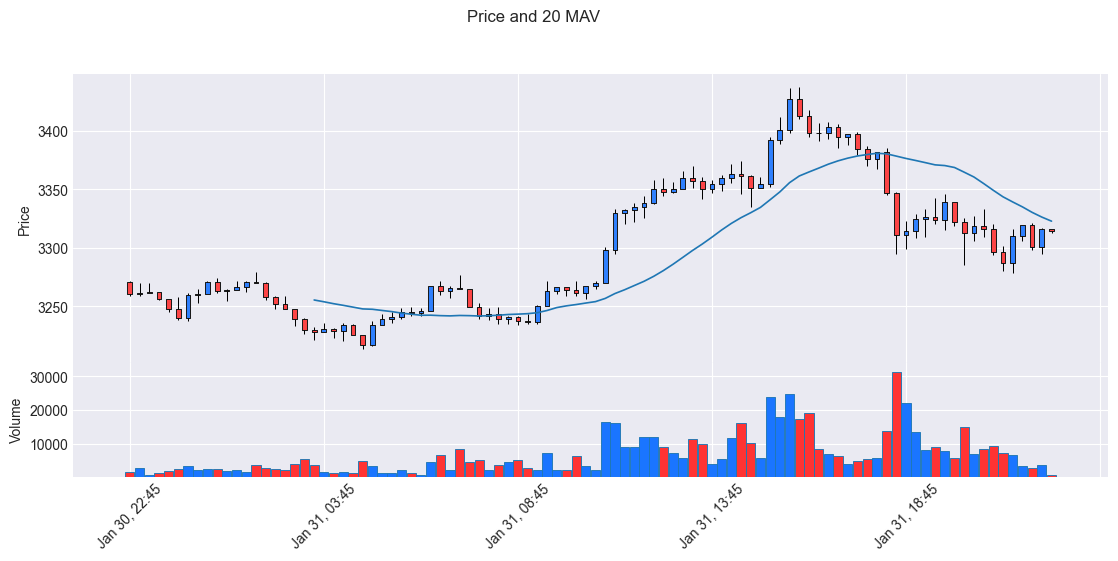

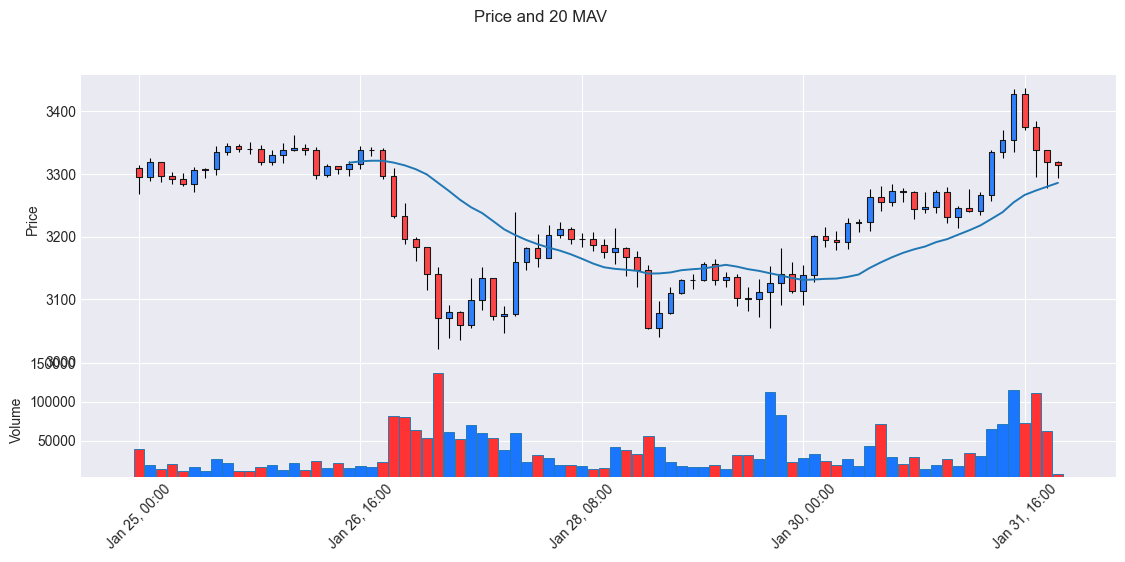

In [14]:
make_candlebars(day_history)
make_candlebars(week_history)

In [15]:
res = ai_client.create(
    [
        ai_client.make_msg(
            "You are professional trader",
            role=ROLE_SYSTEM,
        ),
        ai_client.make_msg(
            text='''What is shown on this image, what are the trends and prices? What do you expect prices to be in a week? If you were making a trade, what would you do?
            Respond with json of this format: 
                { 'complex_explanation': 'you deep analytics of the trend and possibilities', 
                  'simple_explanation': 'simple explanation of trends and predictions', 
                  'trade_suggestion': 'if you were making a trade, what would you do?',
                  'trade_explanation': 'reason about your decision, calculate potential profit and loss from the deal'
                  }
            ''',
            img=make_candlebars(week_history, useBuf=True),
        ),
    ],
    options={ "format": JSON_MODE },
)

res

'{\n  "complex_explanation": "Over the past several days, price appears to have bottomed around the 3050–3100 range before moving back above the 20-day moving average (the solid blue line). After climbing toward the high 3300s to near 3400, there is a slight pullback indicated by a few red candles near the top. Daily volumes have often increased on upward moves, suggesting buyers are actively supporting higher prices. The 20-day moving average is still sloping upward, implying short-term bullish momentum remains in effect, though the market is encountering some overhead resistance around the previous highs near 3400. If the pullback holds near 3300–3350 and volume remains supportive, it would confirm a continuation of the uptrend. Conversely, if price falls decisively below the 20-day moving average, that would point to a deeper correction or a reversal of this recent bounce.",\n  "simple_explanation": "Price recently climbed above the 20-day average, spiked near 3400, and is now pulli

In [21]:
pretty_print_json(res)

{
    "complex_explanation": "Over the past several days, price appears to have bottomed around the 3050\u20133100 range before moving back above the 20-day moving average (the solid blue line). After climbing toward the high 3300s to near 3400, there is a slight pullback indicated by a few red candles near the top. Daily volumes have often increased on upward moves, suggesting buyers are actively supporting higher prices. The 20-day moving average is still sloping upward, implying short-term bullish momentum remains in effect, though the market is encountering some overhead resistance around the previous highs near 3400. If the pullback holds near 3300\u20133350 and volume remains supportive, it would confirm a continuation of the uptrend. Conversely, if price falls decisively below the 20-day moving average, that would point to a deeper correction or a reversal of this recent bounce.",
    "simple_explanation": "Price recently climbed above the 20-day average, spiked near 3400, and i